First 10 rows of generated dataset:
       Value
0  14.251275
1   9.788778
2   9.209122
3   9.209220
4  24.664560
5  16.505809
6   7.884560
7  14.617639
8  12.326504
9   2.414627

Basic Summary Statistics:
             Value
count  1000.000000
mean     12.310005
std       6.867443
min       0.413275
25%       7.247305
50%      10.981564
75%      15.916954
max      38.283422

Fit Quality Comparison:
  Distribution       MSE          AIC  KS Statistic     KS p-value
3        Gamma  0.000015  6483.133832      0.013162   9.942973e-01
5      Weibull  0.000033  6508.756375      0.040355   7.492468e-02
4    Lognormal  0.000036  6546.321246      0.043846   4.151252e-02
0       Normal  0.000111  6694.460245      0.088224   3.196085e-07
1  Exponential  0.000446  7024.824766      0.225353   4.193456e-45
2      Uniform  0.000548  7272.326247      0.352072  2.368703e-111


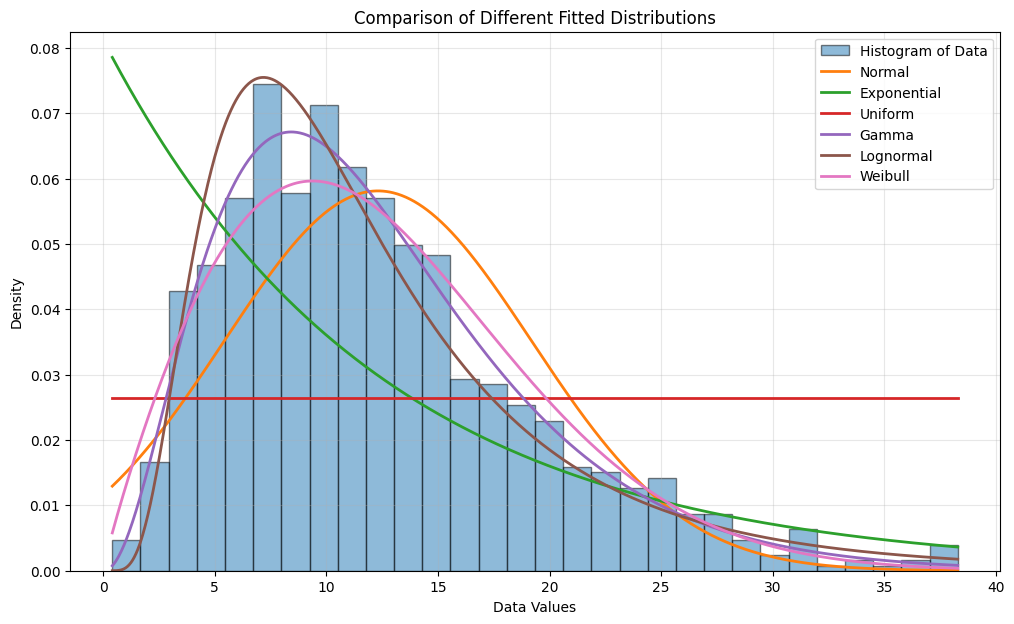

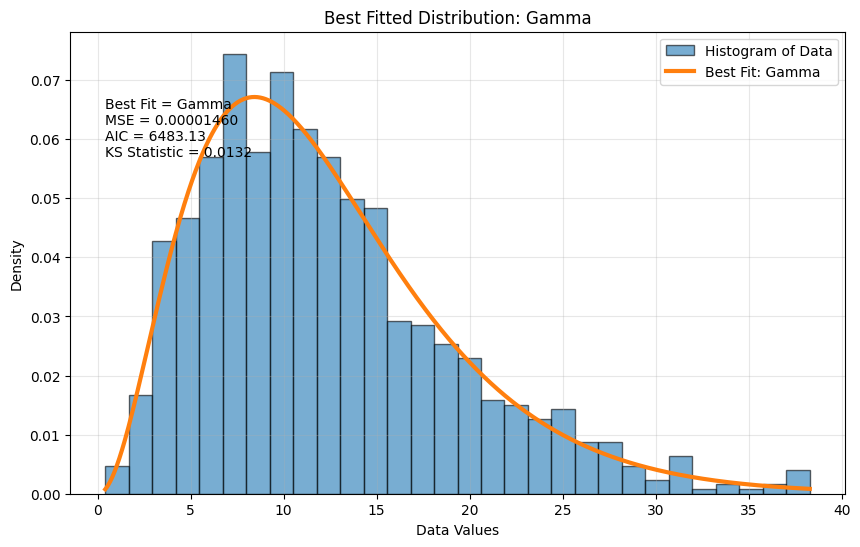

In [2]:
  # Task D Extended:
# Fit multiple probability distributions to the same dataset
# and compare their fit quality.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --------------------------------------------------
# 1. Generate a dataset
# --------------------------------------------------

# Set random seed so results are reproducible
np.random.seed(42)

# Generate a positive, right-skewed dataset
# Example: waiting times, claim amounts, service times, etc.
# Gamma distribution is used here only to create realistic sample data.
data = np.random.gamma(shape=3, scale=4, size=1000)

# Convert into DataFrame
df = pd.DataFrame(data, columns=["Value"])

print("First 10 rows of generated dataset:")
print(df.head(10))

print("\nBasic Summary Statistics:")
print(df.describe())


# --------------------------------------------------
# 2. Define candidate distributions to fit
# --------------------------------------------------

candidate_distributions = {
    "Normal": stats.norm,
    "Exponential": stats.expon,
    "Uniform": stats.uniform,
    "Gamma": stats.gamma,
    "Lognormal": stats.lognorm,
    "Weibull": stats.weibull_min
}


# --------------------------------------------------
# 3. Create histogram values for MSE calculation
# --------------------------------------------------

# density=True means histogram values are converted into density values
hist_values, bin_edges = np.histogram(data, bins=30, density=True)

# Find the center of each histogram bin
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


# --------------------------------------------------
# 4. Fit each distribution and calculate fit quality
# --------------------------------------------------

results = []

for name, distribution in candidate_distributions.items():

    # Some distributions only work properly with positive data.
    # floc=0 forces the distribution to start from 0.
    if name in ["Exponential", "Gamma", "Lognormal", "Weibull"]:
        params = distribution.fit(data, floc=0)
    else:
        params = distribution.fit(data)

    # Calculate fitted PDF values at histogram bin centers
    fitted_pdf_values = distribution.pdf(bin_centers, *params)

    # Mean Squared Error
    mse = np.mean((hist_values - fitted_pdf_values) ** 2)

    # Log-likelihood
    # This measures how likely the data is under the fitted distribution.
    pdf_values_for_data = distribution.pdf(data, *params)

    # Add small value to avoid log(0)
    epsilon = 1e-12
    log_likelihood = np.sum(np.log(pdf_values_for_data + epsilon))

    # Number of fitted parameters
    k = len(params)

    # Akaike Information Criterion
    # Lower AIC means better fit.
    aic = 2 * k - 2 * log_likelihood

    # Kolmogorov-Smirnov test
    # Lower KS statistic means better fit.
    ks_statistic, ks_p_value = stats.kstest(data, distribution.cdf, args=params)

    # Store results
    results.append({
        "Distribution": name,
        "Parameters": params,
        "MSE": mse,
        "AIC": aic,
        "KS Statistic": ks_statistic,
        "KS p-value": ks_p_value
    })


# --------------------------------------------------
# 5. Convert results into a table
# --------------------------------------------------

results_df = pd.DataFrame(results)

# Sort by MSE from best to worst
results_df = results_df.sort_values(by="MSE")

print("\nFit Quality Comparison:")
print(results_df[["Distribution", "MSE", "AIC", "KS Statistic", "KS p-value"]])


# --------------------------------------------------
# 6. Plot histogram with all fitted distributions
# --------------------------------------------------

x = np.linspace(min(data), max(data), 1000)

plt.figure(figsize=(12, 7))

# Plot histogram
plt.hist(
    data,
    bins=30,
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Histogram of Data"
)

# Plot each fitted distribution
for result in results:
    name = result["Distribution"]
    distribution = candidate_distributions[name]
    params = result["Parameters"]

    pdf_curve = distribution.pdf(x, *params)

    plt.plot(
        x,
        pdf_curve,
        linewidth=2,
        label=name
    )

plt.title("Comparison of Different Fitted Distributions")
plt.xlabel("Data Values")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# --------------------------------------------------
# 7. Plot only the best fitting distribution
# --------------------------------------------------

best_fit = results_df.iloc[0]
best_name = best_fit["Distribution"]
best_params = best_fit["Parameters"]

best_distribution = candidate_distributions[best_name]
best_pdf_curve = best_distribution.pdf(x, *best_params)

plt.figure(figsize=(10, 6))

plt.hist(
    data,
    bins=30,
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Histogram of Data"
)

plt.plot(
    x,
    best_pdf_curve,
    linewidth=3,
    label=f"Best Fit: {best_name}"
)

plt.title(f"Best Fitted Distribution: {best_name}")
plt.xlabel("Data Values")
plt.ylabel("Density")

plt.text(
    min(data),
    max(best_pdf_curve) * 0.85,
    f"Best Fit = {best_name}\n"
    f"MSE = {best_fit['MSE']:.8f}\n"
    f"AIC = {best_fit['AIC']:.2f}\n"
    f"KS Statistic = {best_fit['KS Statistic']:.4f}",
    fontsize=10
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()